# Wearable sensors: joint gating across six channels

The UEA BasicMotions set: 80 recordings of four activities (badminton,
running, standing, walking), each a 6-channel series (accelerometer and
gyroscope, x/y/z) of 100 time steps. Small, clean, and exactly the case
RSM's JOINT GATING is built for: the deliverable is a set of TIME WINDOWS
of the shared axis, one gate per window across all six sensors, because
"which part of the movement identifies the activity" is a question about
the axis, not about one sensor.

The second demonstration is channel missingness BELOW the gate: when the
gyroscope drops out for half the recordings (imposed, labelled as such),
the per-channel validity weighting absorbs it and the selected windows do
not move.

In [1]:
import sys
sys.path.insert(0, "../benchmarks")
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_basicmotions

X, V, y, meta = load_basicmotions()
classes = meta["classes"]
print(X.shape, "classes:", classes, "per class:", np.bincount(y).tolist())

(80, 6, 100) classes: ['Badminton', 'Running', 'Standing', 'Walking'] per class: [20, 20, 20, 20]


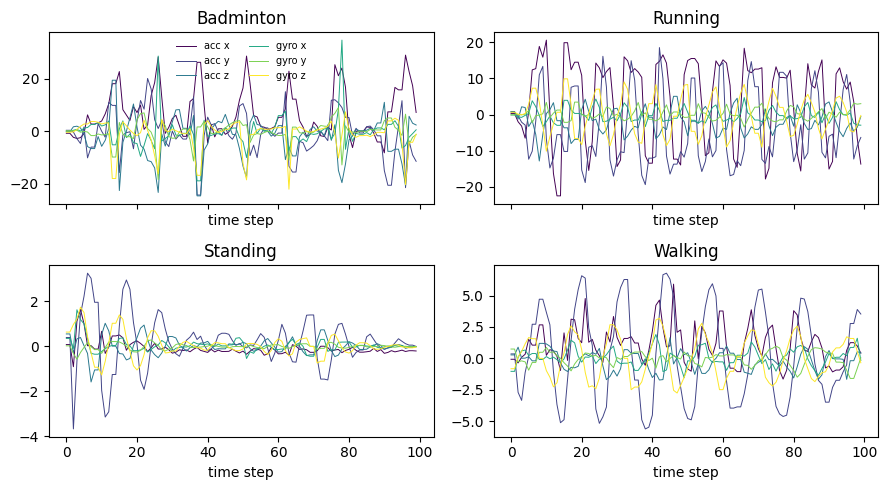

In [2]:
# one recording per class, all six channels (viridis shades = channels)
chan_names = ["acc x", "acc y", "acc z", "gyro x", "gyro y", "gyro z"]
fig, axes = plt.subplots(2, 2, figsize=(9, 5), sharex=True)
for k, ax in enumerate(axes.ravel()):
    i = int(np.flatnonzero(y == k)[0])
    for c in range(6):
        ax.plot(X[i, c], lw=0.7, color=plt.cm.viridis(c / 5),
                label=chan_names[c] if k == 0 else None)
    ax.set_title(classes[k])
    ax.set_xlabel("time step")
axes[0, 0].legend(frameon=False, fontsize=7, ncol=2)
plt.tight_layout()

## Which time windows identify the activity

Ten windows of ten steps; a three-window budget. One gate per window,
shared across the six channels; the head weighs each channel's evidence
inside a kept window freely.

In [3]:
from robustsignalmaker import BootstrapMaskSelector

sel = BootstrapMaskSelector(task="multiclass", segment=10, lam=0.08,
                            n_iter=300, lr=0.1, n_bootstrap=25,
                            target_coverage=3 / 10, seed=0).fit(X, y)
print("selected windows:", sel.selected_segments_.tolist())
print("pi:", [round(float(sel.pi_[s]), 2) for s in sel.selected_segments_])
sel.stability_report()

selected windows: [3, 4, 5]
pi: [0.84, 0.96, 1.0]


{'n_fits': 25,
 'n_failed_fits': 0,
 'tau': 0.84,
 'coverage': 0.3,
 'assessable_universe': 10,
 'n_segments': 10,
 'unassessable_fraction': 0.0,
 'insufficient_evidence': [],
 'pi_mean': 0.6160000000000001,
 'pi_max': 1.0,
 'frac_confident_in': 0.5,
 'frac_confident_out': 0.1,
 'ambiguous_fraction': 0.4,
 'mean_obs_frac': 1.0,
 'strata': 'stratified by class',
 'degenerate': False}

In [4]:
# three windows vs the whole recording, uniform multiclass scorer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

def mc_scores(F, yv, seed=0):
    model = make_pipeline(StandardScaler(),
                          LogisticRegression(max_iter=2000, random_state=seed))
    cv = StratifiedKFold(5, shuffle=True, random_state=seed)
    proba = cross_val_predict(model, F, yv, cv=cv, method="predict_proba")
    return (roc_auc_score(yv, proba, multi_class="ovr", average="weighted"),
            accuracy_score(yv, proba.argmax(1)))

F_seg = X.reshape(80, 6, 10, 10).mean(axis=3)   # per-channel window means
chosen = sel.selected_segments_
auc_sel, acc_sel = mc_scores(F_seg[:, :, chosen].reshape(80, -1), y)
auc_full, acc_full = mc_scores(F_seg.reshape(80, -1), y)
print(f"three windows: AUC-OVR {auc_sel:.3f}, accuracy {acc_sel:.3f}")
print(f"whole series:  AUC-OVR {auc_full:.3f}, accuracy {acc_full:.3f}")

three windows: AUC-OVR 0.970, accuracy 0.875
whole series:  AUC-OVR 0.975, accuracy 0.863


In [5]:
from robustsignalmaker import NestedCV

res = NestedCV(k_outer=4, segment=10, lam=0.08, n_bootstrap=15,
               target_coverage=3 / 10, mnar_guard=False,
               random_state=0).run(X, y)
s = res.summary()
{k: s[k] for k in ("score_name", "score_mean", "baseline_score_mean",
                    "verdict", "selection_stability_adjusted",
                    "mean_n_selected")}

{'score_name': 'AUC-OVR',
 'score_mean': 0.9208333333333334,
 'baseline_score_mean': 0.9650000000000001,
 'verdict': 'preserved',
 'selection_stability_adjusted': 0.6046365914786967,
 'mean_n_selected': 2.75}

Measured: the mid-recording windows (time steps 30 to 60) carry the
activity signature. Two measurements, kept apart, because they say different
things. On a single split, three of ten windows score AUC-OVR 0.970 against
the whole series' 0.975. Under four-fold nested CV, where selection is
refitted inside every fold, it is 0.921 against 0.965, verdict `preserved`.
The nested pair is the honest one, and the wider gap is what small folds
cost: at n=80 with 4 folds every statistic is small-n and the Wilcoxon runs
at its floor. The early windows lose standing either way: recordings begin
near rest, where activities look alike.

## Channel dropout below the gate (imposed)

Suppose the gyroscope failed for every second recording. The gate is
shared across channels, so nothing needs re-designing: the per-channel
validity weighting removes the missing channels' contributions for those
recordings, the sample renormaliser compensates, and support is reported.

In [6]:
V_drop = np.ones_like(X, dtype=bool)
V_drop[::2, 3:, :] = False   # gyro x/y/z lost for half the recordings
sel_drop = BootstrapMaskSelector(task="multiclass", segment=10, lam=0.08,
                                 n_iter=300, lr=0.1, n_bootstrap=25,
                                 target_coverage=3 / 10, seed=0
                                 ).fit(np.where(V_drop, X, np.nan), y, V_drop)
print("selected with gyro dropout:", sel_drop.selected_segments_.tolist())
print("same windows as the complete run:",
      set(sel_drop.selected_segments_) == set(sel.selected_segments_))
print("support:", [round(float(sel_drop.support_[s]), 2)
                   for s in sel_drop.selected_segments_])

selected with gyro dropout: [3, 4, 5]
same windows as the complete run: True
support: [1.0, 1.0, 1.0]


The joint gate holds: losing half the cohort's gyroscopes changes the
evidence weighting, not the answer's coordinate system, and the selected
windows are unchanged. That is the multi-channel design doing what
the design promised.